# **Linear Regression Model Implementation**

This model is being implemented to try to answer question #8 that we originally posed at the beggining of our investigation. That question was:

> 8.How does literacy level **(read_all_mean)** impact student performance in mathematics **(math_all_mean)**?

In addition to this base question, we wanted to also consider if any of the following variables could help predict a students literacy level:
- SES
- **mental health**
- **exercise (enough or not enough)**
- food/hunger
- growth mindset
- love of learning
- % GDP spent on education

An initial investigation of the data of interest revealed that the variables for mental health and exercise were missing data for a considerable number of countries, 66 and 67 countries out of 81, respectively. For this reason, these variables were not considered in the actual model implementation.

## **Import and clean data**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("dfCOG.csv")

In [ ]:
df_lr = df[['country','math_all_mean','read_all_mean','ses_all_mean','ST258Q01JA_1.0_proportion','ST258Q01JA_2.0_proportion','ST258Q01JA_3.0_proportion','ST258Q01JA_4.0_proportion',
            'ST258Q01JA_5.0_proportion','ST263Q02JA_1.0_proportion','ST263Q02JA_2.0_proportion','ST263Q02JA_3.0_proportion','ST263Q02JA_4.0_proportion','ST301Q10JA_1.0_proportion',
            'ST301Q10JA_2.0_proportion','ST301Q10JA_3.0_proportion','ST301Q10JA_4.0_proportion','ST301Q10JA_5.0_proportion','ed_percent_gdp']]
df_lr.head()

,country,math_all_mean,read_all_mean,ses_all_mean,ST258Q01JA_1.0_proportion,ST258Q01JA_2.0_proportion,ST258Q01JA_3.0_proportion,ST258Q01JA_4.0_proportion,ST258Q01JA_5.0_proportion,ST263Q02JA_1.0_proportion,ST263Q02JA_2.0_proportion,ST263Q02JA_3.0_proportion,ST263Q02JA_4.0_proportion,ST301Q10JA_1.0_proportion,ST301Q10JA_2.0_proportion,ST301Q10JA_3.0_proportion,ST301Q10JA_4.0_proportion,ST301Q10JA_5.0_proportion,ed_percent_gdp
0,Bulgaria,417,404,-0.27,0.7780,0.0500,0.0336,0.0164,0.1221,0.2248,0.3649,0.3086,0.1017,0.0609,0.0551,0.1437,0.4759,0.2644,4.730330
1,Cambodia,336,329,-2.01,0.3225,0.2248,0.1615,0.0685,0.2227,NaN,NaN,NaN,NaN,0.0223,0.0469,0.0928,0.6536,0.1843,2.951152
2,Canada,497,507,0.38,0.9139,0.0278,0.0127,0.0049,0.0408,0.1666,0.4581,0.3042,0.0711,0.0194,0.0346,0.2334,0.4772,0.2354,4.139572
3,Chile,412,448,-0.51,0.8692,0.0484,0.0133,0.0065,0.0625,0.2324,0.3795,0.3042,0.0839,0.0260,0.0206,0.1568,0.4428,0.3538,4.999240
4,Chinese Taipei,547,515,-0.19,0.9028,0.0506,0.0235,0.0064,0.0168,0.1281,0.4212,0.3653,0.0854,0.0126,0.0267,0.3328,0.4449,0.1829,4.615470


In [ ]:
df_lr.shape

(81, 19)

In [ ]:
df_lr.isnull().sum()

,0
country,0
math_all_mean,0
read_all_mean,0
ses_all_mean,1
ST258Q01JA_1.0_proportion,15
ST258Q01JA_2.0_proportion,15
ST258Q01JA_3.0_proportion,15
ST258Q01JA_4.0_proportion,15
ST258Q01JA_5.0_proportion,15
ST263Q02JA_1.0_proportion,6


In [ ]:
df_lr = df_lr[~df_lr['ST258Q01JA_1.0_proportion'].isna()]
df_lr = df_lr[~df_lr['ST263Q02JA_1.0_proportion'].isna()]
df_lr = df_lr[~df_lr['ST301Q10JA_1.0_proportion'].isna()]
df_lr.shape

(61, 19)

In [ ]:
df_lr.isnull().sum()

,0
country,0
math_all_mean,0
read_all_mean,0
ses_all_mean,0
ST258Q01JA_1.0_proportion,0
ST258Q01JA_2.0_proportion,0
ST258Q01JA_3.0_proportion,0
ST258Q01JA_4.0_proportion,0
ST258Q01JA_5.0_proportion,0
ST263Q02JA_1.0_proportion,0


In [ ]:
df_lr.head()

,country,math_all_mean,read_all_mean,ses_all_mean,ST258Q01JA_1.0_proportion,ST258Q01JA_2.0_proportion,ST258Q01JA_3.0_proportion,ST258Q01JA_4.0_proportion,ST258Q01JA_5.0_proportion,ST263Q02JA_1.0_proportion,ST263Q02JA_2.0_proportion,ST263Q02JA_3.0_proportion,ST263Q02JA_4.0_proportion,ST301Q10JA_1.0_proportion,ST301Q10JA_2.0_proportion,ST301Q10JA_3.0_proportion,ST301Q10JA_4.0_proportion,ST301Q10JA_5.0_proportion,ed_percent_gdp
0,Bulgaria,417,404,-0.27,0.7780,0.0500,0.0336,0.0164,0.1221,0.2248,0.3649,0.3086,0.1017,0.0609,0.0551,0.1437,0.4759,0.2644,4.730330
2,Canada,497,507,0.38,0.9139,0.0278,0.0127,0.0049,0.0408,0.1666,0.4581,0.3042,0.0711,0.0194,0.0346,0.2334,0.4772,0.2354,4.139572
3,Chile,412,448,-0.51,0.8692,0.0484,0.0133,0.0065,0.0625,0.2324,0.3795,0.3042,0.0839,0.0260,0.0206,0.1568,0.4428,0.3538,4.999240
4,Chinese Taipei,547,515,-0.19,0.9028,0.0506,0.0235,0.0064,0.0168,0.1281,0.4212,0.3653,0.0854,0.0126,0.0267,0.3328,0.4449,0.1829,4.615470
5,Colombia,383,409,-1.07,0.8670,0.0613,0.0270,0.0075,0.0372,0.1192,0.3063,0.4838,0.0907,0.0378,0.0201,0.0661,0.5117,0.3643,4.615470


## **Linear Regression for original two variables in question 8**

In [ ]:
X1 = df_lr[['read_all_mean']]
y1 = df_lr[['math_all_mean']]

#30% fort test and 70% for train
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.30, random_state = 00000)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)
X1_sm = sm.add_constant(X1_test)
results1 = sm.OLS(y1_test,X1_sm).fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:          math_all_mean   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     95.04
Date:                Sun, 13 Apr 2025   Prob (F-statistic):           2.24e-08
Time:                        21:53:34   Log-Likelihood:                -84.358
No. Observations:                  19   AIC:                             172.7
Df Residuals:                      17   BIC:                             174.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.7625     46.939     -0.080

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


## **Linear Regression for all variables of interest**

In [ ]:
X2 = df_lr.drop(['math_all_mean','country'], axis=1)
y2 = df_lr[['math_all_mean']]

#30% fort test and 70% for train
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.30, random_state = 00000)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
X2_sm = sm.add_constant(X2_test)
results2 = sm.OLS(y2_test,X2_sm).fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:          math_all_mean   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                     4931.
Date:                Sun, 13 Apr 2025   Prob (F-statistic):             0.0112
Time:                        21:53:34   Log-Likelihood:                 5.4247
No. Observations:                  19   AIC:                             25.15
Df Residuals:                       1   BIC:                             42.15
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


## **Linear Regression with aggregate variables**

In [ ]:
#Creating aggregate variables for ST258 (variable for hunger), ST263 (variable for growth mindset), and ST301 (variable for love of learning).
#Aggregate variable for hunger is the percentage of students who reported not eating 4 or more times a week in the last 30 days due to not haveing enough money
#Aggregate variable for growth mindset is the percentage of students that have a high growth mindset, which means answering agree or strongly agree to the question
#Aggregate variable for love of learning is the percentage of students that have a high love of learning, which means answering agree or stronly agree to the question
df_lr_agg = df_lr.copy()
df_lr_agg['Percent High Hunger'] = df_lr_agg['ST258Q01JA_4.0_proportion'] + df_lr_agg['ST258Q01JA_5.0_proportion']
df_lr_agg['Percent High Growth Mindset'] = df_lr_agg['ST263Q02JA_3.0_proportion'] + df_lr_agg['ST263Q02JA_4.0_proportion']
df_lr_agg['Percent High Love of Learning'] = df_lr_agg['ST301Q10JA_4.0_proportion'] + df_lr_agg['ST301Q10JA_5.0_proportion']

#Drop all of the proportion variables
df_lr_agg.drop(columns=['ST258Q01JA_1.0_proportion','ST258Q01JA_2.0_proportion','ST258Q01JA_3.0_proportion','ST258Q01JA_4.0_proportion','ST258Q01JA_5.0_proportion',
                'ST263Q02JA_1.0_proportion','ST263Q02JA_2.0_proportion','ST263Q02JA_3.0_proportion','ST263Q02JA_4.0_proportion',
                'ST301Q10JA_1.0_proportion','ST301Q10JA_2.0_proportion','ST301Q10JA_3.0_proportion','ST301Q10JA_4.0_proportion','ST301Q10JA_5.0_proportion'], inplace=True)

df_lr_agg.head()

,country,math_all_mean,read_all_mean,ses_all_mean,ed_percent_gdp,Percent High Hunger,Percent High Growth Mindset,Percent High Love of Learning
0,Bulgaria,417,404,-0.27,4.730330,0.1385,0.4103,0.7403
2,Canada,497,507,0.38,4.139572,0.0457,0.3753,0.7126
3,Chile,412,448,-0.51,4.999240,0.0690,0.3881,0.7966
4,Chinese Taipei,547,515,-0.19,4.615470,0.0232,0.4507,0.6278
5,Colombia,383,409,-1.07,4.615470,0.0447,0.5745,0.8760


In [ ]:
X3 = df_lr_agg.drop(['math_all_mean','country'], axis=1)
y3 = df_lr_agg['math_all_mean']

In [ ]:
#30% fort test and 70% for train
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size = 0.30, random_state = 00000)

In [ ]:
#Functions to perform subset selection for our new dataframe with aggregate variables

def processSubset(feature_set):
    # Fit model on feature_set and calculate RSS
    X_train = sm.add_constant(X3_train[list(feature_set)], has_constant='add')
    X_test = sm.add_constant(X3_test[list(feature_set)], has_constant='add')
    model = sm.OLS(y3_train,X_train)
    regr = model.fit()
    RSS = ((y3_test - regr.predict(X_test))**2).sum()
    return {"model":regr, "RSS":RSS}

def getBest(k):
    tic = time.time()
    results = []
    for combo in itertools.combinations(X3.columns, k):
      results.append(processSubset(combo))

    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)

    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]

    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")

    # Return the best model, along with some other useful information about the model
    return best_model

In [ ]:
models_best = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()
for i in range(1,7):
    models_best.loc[i] = getBest(i)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

Processed 6 models on 1 predictors in 0.0360867977142334 seconds.
Processed 15 models on 2 predictors in 0.14902591705322266 seconds.
Processed 20 models on 3 predictors in 0.18065667152404785 seconds.
Processed 15 models on 4 predictors in 0.4769706726074219 seconds.
Processed 6 models on 5 predictors in 0.30593323707580566 seconds.
Processed 1 models on 6 predictors in 0.0350341796875 seconds.
Total elapsed time: 1.2107954025268555 seconds.


In [ ]:
models_best

,RSS,model
1,8178.708994,<statsmodels.regression.linear_model.Regressio...
2,6052.686324,<statsmodels.regression.linear_model.Regressio...
3,6073.444983,<statsmodels.regression.linear_model.Regressio...
4,6213.314325,<statsmodels.regression.linear_model.Regressio...
5,6841.139077,<statsmodels.regression.linear_model.Regressio...
6,7092.381148,<statsmodels.regression.linear_model.Regressio...


<ipython-input-19-91582e38d2d9>:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)
<ipython-input-19-91582e38d2d9>:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  aic = models_best.apply(lambda row: row[1].aic, axis=1)
<ipython-input-19-91582e38d2d9>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bic = models_best.apply(lambda row: row[1].bic, axis=1)


Text(0, 0.5, 'BIC')

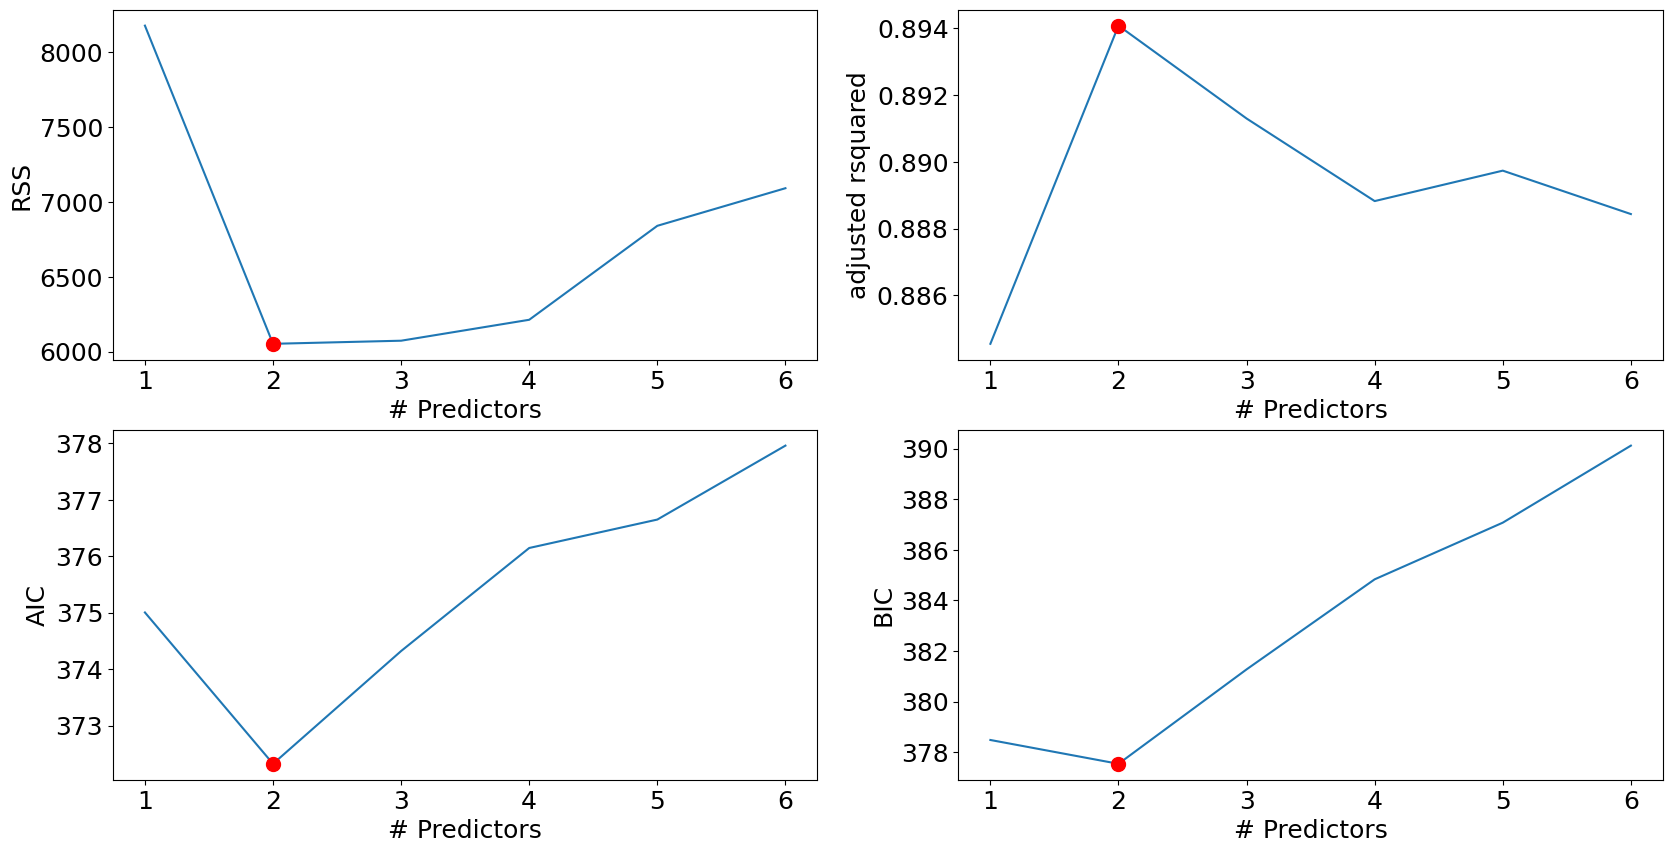

In [ ]:
plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})

# Set up a 2x2 grid so we can look at 4 plots at once
# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector
plt.subplot(2, 2, 1)
plt.plot(models_best["RSS"])
plt.plot((models_best["RSS"].argmin() + 1), models_best["RSS"].min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('RSS')

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector

rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)

plt.subplot(2, 2, 2)
plt.plot(rsquared_adj)
plt.plot((rsquared_adj.argmax() + 1), rsquared_adj.max(), "or")
plt.xlabel('# Predictors')
plt.ylabel('adjusted rsquared')

# We'll do the same for AIC and BIC, this time looking for the models with the SMALLEST statistic
aic = models_best.apply(lambda row: row[1].aic, axis=1)

plt.subplot(2, 2, 3)
plt.plot(aic)
plt.plot((aic.argmin() + 1), aic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('AIC')

bic = models_best.apply(lambda row: row[1].bic, axis=1)

plt.subplot(2, 2, 4)
plt.plot(bic)
plt.plot((bic.argmin() + 1), bic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('BIC')

In [ ]:
print(models_best.loc[2, "model"].summary())

                            OLS Regression Results                            
Dep. Variable:          math_all_mean   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     174.0
Date:                Sun, 13 Apr 2025   Prob (F-statistic):           3.66e-20
Time:                        21:53:38   Log-Likelihood:                -183.16
No. Observations:                  42   AIC:                             372.3
Df Residuals:                      39   BIC:                             377.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

## **Investigation into whether breaking out the relevant aggregate variable back into its proportions improves the model at all**

In [ ]:
X4 = df_lr[['read_all_mean','ST301Q10JA_1.0_proportion','ST301Q10JA_2.0_proportion','ST301Q10JA_3.0_proportion','ST301Q10JA_4.0_proportion','ST301Q10JA_5.0_proportion']]
y4 = df_lr[['math_all_mean']]

#30% fort test and 70% for train
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size = 0.30, random_state = 00000)

model4 = LinearRegression()
model4.fit(X4_train, y4_train)
X4_sm = sm.add_constant(X4_test)
results2 = sm.OLS(y4_test,X4_sm).fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:          math_all_mean   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     21.92
Date:                Sun, 13 Apr 2025   Prob (F-statistic):           8.24e-06
Time:                        21:53:39   Log-Likelihood:                -78.697
No. Observations:                  19   AIC:                             171.4
Df Residuals:                      12   BIC:                             178.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


## **Model Comparison and Results**

In [ ]:
y1_pred = model1.predict(X1_test)
rmse1 = np.sqrt(mean_squared_error(y1_test, y1_pred))
rmse3 = np.sqrt(np.mean(models_best.loc[2, "model"].resid**2))

In [ ]:
#['All Variables w/ All Proportions',results2.rsquared_adj,results2.aic,results2.bic],

data = [['Just Reading',results1.rsquared,results1.aic,results1.bic,rmse1],
        ['Best Model w/ Aggregation Variables',models_best.loc[2, "model"].rsquared_adj,models_best.loc[2, "model"].aic,models_best.loc[2, "model"].bic,rmse3]]
comparison = pd.DataFrame(data, columns=['Model','Adj R^2','AIC','BIC','RMSE'])
display(comparison)

,Model,Adj R^2,AIC,BIC,RMSE
0,Just Reading,0.848269,172.716448,174.605326,20.747491
1,Best Model w/ Aggregation Variables,0.894075,372.323663,377.536672,18.954805


Why the model was chosen (justify selection based on dataset characteristics)
- This model was chosen because in our initial Exploratory Data Analysis, we generated a scatter plot of Math Performance Score versus Reading Performance score. The resulting plot seemed to suggest a strong positive linear relationship. Therefore, we figured that linear regression would be a good model to utilize to investigate the relationship between Math Performance and Reading Performance along with other behavioral variables that could realistically influence Math performance.

Model assumptions
- The first assumption that was made for this model was that the relationship between the dependent variable, Math Performance, and the independent variables, Reading Performance, Socioeconomic Status Score, a Hunger Variable,
a Growth Mindset variable, a Love of Learning variable, and Percent of GDP Spent on Education. The second assumption was that the chosen behavioral variables actually had some impact on a student's Math Performance score.

Hyperparameter tuning (adjustments to improve model performance)
- The adjustments that were made during model development to improve performance was adjusting the number of variables that were being considered in model construction. We started with just considering a model that only included Reading Performance as an independent variable. We then constructed a model that included all of the additional independent variables mentioned above that we wanted to include. Next, we constructed aggregate variables for each behavioral variable instead of including each individual proportion variable. We used these new aggregate variables to construct additional models for evaluation.

Challenges faced & solutions (if applicable)
- A challenge that we faced was the size of our dataset. Originally, our dataset included 81 countries to examine. However, after cleaning the data and removing countries that were missing data for our variables we wanted to consider, we were left with 61 countries. Although this was still a good size, we did run into issues when constructing our second model. The second model included all of our proportions of each variable, instead of an aggregated variable. This meant that there were 17 independent variables in total. With a 70/30 split for training and testing data, we were only left with one degree of freedom for the model, meaning the data was fit almost perfectly. This was not ideal and therefore this model was not considered any further.\
Our first solution was a one variable model that predicted Math performance based on Reading performance. This model performed relatively well. Next, we aggregated our behavioral variables. The aggregate variable for hunger was the percentage of students who reported not eating 4 or more times a week in the last 30 days due to not having enough money. The aggregate variable for growth mindset was the percentage of students that have a high growth mindset, which means answering agree or strongly agree to the relevant question. The aggregate variable for love of learning was the percentage of students that have a high love of learning, which means answering agree or strongly agree to the relevant question. We then conducted subset regression analysis to determine the best model by considering every possible combinations of variables from the 7 total variables. This analysis yielded the result of a two variable model including Reading Performance and Love of Learning aggregate variable.\
Lastly, we used Adjusted R^2, AIC, BIC, and RMSE to evaluate and compare each model. Based on the resulting metrics, we concluded that the two parameter model with the reading performance variable and the aggregate love of learning variable was the best model. We concluded this based on a better adjusted R^2 value as well as a better RMSE. AIC and BIC were higher for our chosen model compared to the other considered model. However, we know that both AIC and BIC penalize a model for its complexity, yielding a higher value. Since our chosen model only had 2 parameters compared to the other model's one parameter, we felt as though this additional complexity was not excessive and therefore chose our model based on adjusted R^2 and RMSE.